# Competition Model: Fitting to Experimental Data

**Model:** Two proteins (A, B) competing for a limiting nuclear import factor

## Model Schematic

![Competition Model](diagram/competition_model.png)

The diagram shows protein A cycling between cytoplasmic free form ($A_f$), factor-bound complex ($AF$), and nuclear form ($A_n$). Protein B (not shown) follows identical kinetics. Both proteins compete for the limited factor F, creating competitive inhibition for nuclear import.

## Mathematical Derivation

### Model Description

We consider two proteins, A and B, that compete for a limiting assembly factor F that facilitates their nuclear import:

1. **Binding:** Both proteins bind the assembly factor in the cytoplasm with equal affinity
2. **Nuclear import:** Only protein-factor complexes are imported into the nucleus, at equal rates
3. **Factor recycling:** Upon import, the factor is released
4. **Differential degradation:** Proteins degrade in both compartments, with potentially different rates for A and B
5. **Protection:** When bound to the factor, proteins are protected from degradation
6. **Synthesis:** Both proteins are synthesised at the same constant rate

### Species

**Cytoplasm:** $A_f$, $B_f$, $F_f$ (free proteins/factor), $AF$, $BF$ (complexes)

**Nucleus:** $A_n$, $B_n$ (nuclear proteins)

### Reactions

**Binding equilibria and nuclear import:**

$$
\begin{aligned}
A_f + F_f &\xrightleftharpoons[k_{\text{off}}]{k_{\text{on}}} AF \xrightarrow{k_{\text{import}}} A_n + F_f \\
B_f + F_f &\xrightleftharpoons[k_{\text{off}}]{k_{\text{on}}} BF \xrightarrow{k_{\text{import}}} B_n + F_f
\end{aligned}
$$

**Degradation:**

$$
\begin{aligned}
A_f &\xrightarrow{\delta_f^A} \emptyset , \quad
B_f \xrightarrow{\delta_f^B} \emptyset \\
A_n &\xrightarrow{\delta_n^A} \emptyset ,  \quad
B_n \xrightarrow{\delta_n^B} \emptyset 
\end{aligned}
$$

**Synthesis:**

$$
\emptyset \xrightarrow{k_s} A_f, \quad \emptyset \xrightarrow{k_s} B_f
$$

### Quasi-Steady State Approximation

The ODE governing the complex $AF$ is

$$
\frac{d(AF)}{dt} = k_{\text{on}} A_f F_f - (k_{\text{off}} + k_{\text{import}}) AF
$$

Under the quasi-steady-state assumption that the complex equilibrates rapidly relative to the free species - i.e. the binding rate $k_{\text{on}} F_f$ and the complex-loss rate $k_{\text{off}} + k_{\text{import}}$ are both large compared with the slow rates $k_s/X_f$, $\delta_f^A$, $\delta_f^B$, $\delta_n$ - this simplifies to

$$
AF = \frac{A_fF_f}{K_M}, \quad BF = \frac{B_fF_f}{K_M}
$$

where

$$
K_M = \frac{k_{\text{off}} + k_{\text{import}}}{k_{\text{on}}}
$$

is the Michaelis constant.

### Conservation of Factor

$$
F_{\text{total}} = F_f + AF + BF = F_f\left(1 + \frac{A_f + B_f}{K_M}\right)
$$

Therefore:

$$
F_f = \frac{F_{\text{total}}}{1 + (A_f + B_f)/K_M} = \frac{F_{\text{total}}K_M}{K_M + A_f + B_f}
$$

### Simplified ODEs

The system reduces to:

$$
\begin{aligned}
\frac{dA_f}{dt} &= k_s - \frac{k_{\text{import}} F_{\text{total}} A_f}{K_M + A_f + B_f} - \delta_f^A A_f \\
\frac{dB_f}{dt} &= k_s - \frac{k_{\text{import}} F_{\text{total}} B_f}{K_M + A_f + B_f} - \delta_f^B B_f \\
\frac{dA_n}{dt} &= \frac{k_{\text{import}} F_{\text{total}} A_f}{K_M + A_f + B_f} - \delta_n^A A_n \\
\frac{dB_n}{dt} &= \frac{k_{\text{import}} F_{\text{total}} B_f}{K_M + A_f + B_f} - \delta_n^B B_n
\end{aligned}
$$

This is a competitive import system where A and B compete for the limited factor F.

### Identifiability and the cytoplasmic:nuclear POLR2A constraint

$k_{\text{import}}$ and $F_{\text{total}}$ enter every equation **only** as the product
$V_{\max} = k_{\text{import}} F_{\text{total}}$, so the nuclear trajectories cannot separate them.
We therefore fit $V_{\max}$ directly.

$F_{\text{total}}$ is not meaningless, however: its value contributes to how much protein is in
in the cytoplasmic complex, $AF = A_f F_{\text{total}} / (K_M + A_f + B_f)$, and so it contributes 
to determining the *total* cytoplasmic signal $A_f + AF$. We therefore fix it using a 
nuclear:cytoplasmic POLR2A ratio approximated from experiments,

$$
\frac{A_f + AF}{A_n} = R_{\mathrm{cyt}}
\qquad\Longrightarrow\qquad
F_{\text{total}} = \frac{(K_M + A_f + B_f)\,(R_{\mathrm{cyt}} A_n - A_f)}{A_f}
$$

Because $A_f$, $B_f$ and $A_n$ depend only on $(k_s, V_{\max}, K_M, \delta_f^A, \delta_f^B)$ and not
on $F_{\text{total}}$ ($F_{\text{total}}$ only appears as part of $V_{\max}$ in these ODEs), this
can be solved exactly at each fit evaluation rather than fitted.

The measurement then constrains the fit from both sides:

- **Upper:** $A_f < R_{\mathrm{cyt}} A_n$. The free pool alone must not already exceed the
  measured cytoplasmic signal, or no non-negative $F_{\text{total}}$ exists.
- **Lower:** $F_{\text{total}} \ge \phi\, A_f$ (`F_TOTAL_FLOOR_FRAC`). Without this the fit escapes
  to the degenerate corner $F_{\text{total}} \to 0$, $k_{\text{import}} \to \infty$. Since the
  factor is essentially fully occupied, $k_{\text{import}} = V_{\max}/F_{\text{total}}$ is imports
  per factor molecule per hour, so a floor on $F_{\text{total}}$ is really a ceiling on how fast
  the factor can cycle.

Both are imposed as penalties during model fitting.

### Flux

At steady state, synthesis of each protein balances two exits from the free cytoplasmic pool -
import into the nucleus, and degradation in the cytoplasm:

$$
k_s \;=\; \underbrace{\frac{V_{\max} X_f}{K_M + A_f + B_f}}_{\text{imported}} \;+\; \underbrace{\delta_f^X X_f}_{\text{degraded in cytoplasm}}
$$

so the imported fraction is the first term divided by $k_s$ and the degraded fraction is the second
term divided by $k_s$.

### Parameterization for Fitting

**Free parameters (5):**
- $k_s$ (synthesis rate)
- $V_{\max} = k_{\text{import}} F_{\text{total}}$ (maximal import flux)
- $K_M$ (Michaelis constant)
- $\delta_f^A$ (cytoplasmic degradation of A)
- $\delta_{\mathrm{degron}}^B$ (auxin degradation increment; added to both $\delta_f^B$ and $\delta_n^B$)

**Determined by the cytoplasmic:nuclear constraint:**
- $F_{\text{total}}$, and hence $k_{\text{import}} = V_{\max}/F_{\text{total}}$

**Fixed parameters (from experimental measurements):**
- $\delta_n^A$ (nuclear removal rate for A) from bleach chase experiments
- $\delta_n^B = f_B \cdot \delta_n^A$ where $f_B = $ RFP/GFP normalization ratio (from steady-state)
- $R_{\mathrm{cyt}} = (A_f + AF)/A_n$ in unperturbed cells (`CYTO_NUC_RATIO`)

**Auxin perturbation:** additive in *both* compartments, $\delta_n^B \to \delta_n^B + \delta_{\mathrm{degron}}^B$ and $\delta_f^B \to \delta_f^B + \delta_{\mathrm{degron}}^B$, with $\delta_{\mathrm{degron}}^B$ fitted (also $\delta_f^B = \delta_f^A$ in the control condition)

**Experimental conditions:**
- **VEH_AUX (Inhibitor):** Start at control steady state, step-increase in B degradation upon 5-Ph-IAA addition.
- **AUX_VEH (Washout):** Start at perturbed steady state, step-decrease B degradation back to control upon 5-Ph-IAA removal.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize, differential_evolution
from scipy.integrate import solve_ivp
import warnings
import time

from models import (
    competition_steady_state,
    max_system_rate,
    simulate_competition_trajectory,
)
from utils import (
    save_parameters,
    load_experimental_data,
    calculate_time_averages,
    plot_data_preview,
)

warnings.filterwarnings("ignore")

# Data directory (all input CSVs)
DATA_DIR = Path("../data")

# Small constant guarding ratio denominators
EPS_RATIO = 1e-12

# Random seed for reproducible fitting
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting style
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## Load Experimental Data

Loaded data for conditions: ['VEH_AUX', 'AUX_VEH']

Data points per condition:
  VEH_AUX: 24 time points
  AUX_VEH: 24 time points


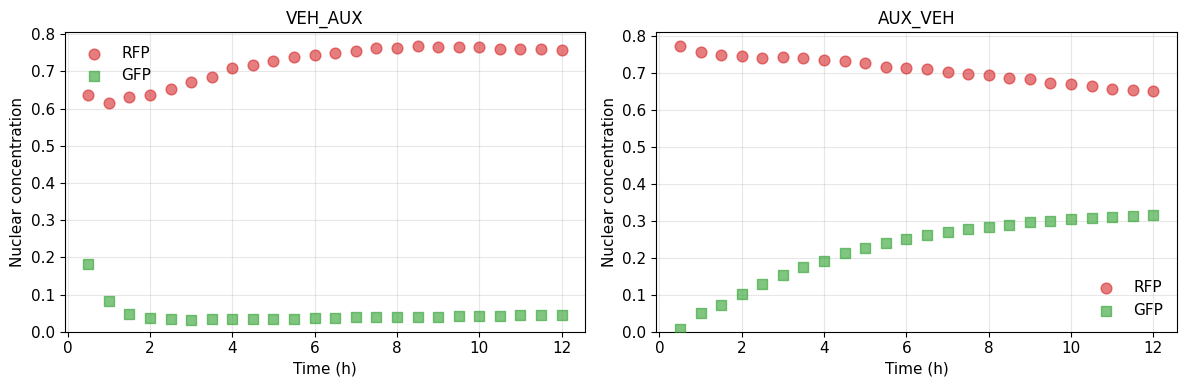

In [2]:
# Data normalization factors (from steady-state mCherry/mClover ratio)
# Note this is not trivially calculated and requires equality of POLR2A IF
# between three cell lines: wild-type, mAC-POLR2A, mCherry-POLR2A.
RFP_NORMALIZATION = 0.5994
GFP_NORMALIZATION = 0.4153

# Load and normalize timecourse data
data_path = DATA_DIR / "mACmCh_LiveCellWashout_Values_ByExperiment.csv"
data = load_experimental_data(
    data_path, {"RFP": RFP_NORMALIZATION, "GFP": GFP_NORMALIZATION}
)

# Calculate time-averaged data for fitting
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours for fitting (where bleach correction
# is more manageable)
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

print(f"Loaded data for conditions: {list(data_averaged.keys())}")
print(f"\nData points per condition:")
for code, df in data_averaged.items():
    print(f"  {code}: {len(df)} time points")

# Preview the data
plot_data_preview(data_averaged, fit_conditions)

## Fixed Parameters from Experimental Measurements

In [3]:
# Load bleach chase data to get measured removal rate
bleach_chase_path = DATA_DIR / "mACmCh_BleachChase_ByExperiment.csv"
bleach_chase_df = pd.read_csv(bleach_chase_path, index_col=0)

# Calculate DELTA_N_A as mean RemovalRate_perhr for VEH treatment
# Note this incorporates dilution due to cell growth
veh_data = bleach_chase_df[bleach_chase_df["Treatment"] == "VEH"]
DELTA_N_A = veh_data["RemovalRate_perhr"].mean()

# Other fixed parameters
# Model B as a less stable A (nucleus) to achieve correct
# relative abundance
DELTA_N_B_FACTOR = RFP_NORMALIZATION / GFP_NORMALIZATION
DELTA_N_B = DELTA_N_B_FACTOR * DELTA_N_A  # Basal nuclear removal rate for B

# Measured cytoplasmic:nuclear ratio of POLR2A in unperturbed cells.
# (A_f + AF)/A_n at the control steady state.
# Used to constrain F_total (see derivation above).
CYTO_NUC_RATIO = 0.2

# Two-sided constraint settings
CYTO_NUC_MARGIN = 0.98  # keep A_f strictly inside the feasible region

# Floor on the factor pool is specified as a fraction of the free protein
# pool: F_total >= phi * A_f. This is quite arbitrary. F should be limiting
# but not implausibly limiting. Equivalently this acts an upper limit on
# the import turnover number k_import = V_max / F_total.
# We choose F_total min to be 5 or 10% of A_f.
F_TOTAL_FLOOR_FRAC = 0.05

print("Fixed parameters and constraints:")
print(
    f"  δ_n^A (RFP nuclear) = {DELTA_N_A:.4f} hr⁻¹ (from bleach chase data, n={len(veh_data)})"
)
print(f"  δ_n^B factor = {DELTA_N_B_FACTOR:.4f}")
print(f"  δ_n^B (control) = {DELTA_N_B:.4f} hr⁻¹")
print(f"  cytoplasmic:nuclear ratio (VEH) = {CYTO_NUC_RATIO}")
print(f"  F_total floor = {F_TOTAL_FLOOR_FRAC:.0%} of A_f")

Fixed parameters and constraints:
  δ_n^A (RFP nuclear) = 0.1352 hr⁻¹ (from bleach chase data, n=3)
  δ_n^B factor = 1.4433
  δ_n^B (control) = 0.1952 hr⁻¹
  cytoplasmic:nuclear ratio (VEH) = 0.2
  F_total floor = 5% of A_f


## Define Fitting Objective

In [4]:
# relative weight of RFP in 5-Ph-IAA in fitting
RFP_RECOVERY_WEIGHT = 1

# the initial decay of GFP is more information-rich
# than the later part of the curve, we we increase it's weight in the fit.
EARLY_GFP_WEIGHT = 3

# Penalty weights for the two-sided cytoplasmic constraint (dimensionless)
CYTO_NUC_PENALTY = 1e3
F_TOTAL_PENALTY = 1e3

# Reject parameter sets whose fastest rate constant exceeds this (hr^-1).
MAX_SYSTEM_RATE = 1e3


def solve_F_total(A_f, B_f, A_n, K_M, ratio=None):
    """
    F_total implied by the measured cytoplasmic:nuclear ratio.

    The trajectories depend on the factor only through V_max = k_import * F_total, so
    F_total is invisible to the nuclear fit. It is fixed instead by the cytoplasmic
    signal, which includes factor-bound protein AF = A_f F_total / (K_M + A_f + B_f):

        (A_f + AF) / A_n = ratio
        =>  F_total = (K_M + A_f + B_f) (ratio * A_n - A_f) / A_f

    Function returns 0.0 (rather than a NaN) when the free pool alone already
    accounts for the whole cytoplasmic signal, so that downstream arithmetic stays
    finite; the infeasibility is handled by the penalty in `constraint_penalty`
    instead.
    """
    if ratio is None:
        ratio = CYTO_NUC_RATIO
    if A_f <= 0 or A_n <= 0:
        return 0.0
    headroom = ratio * A_n - A_f
    if headroom <= 0:
        return 0.0
    return (K_M + A_f + B_f) * headroom / A_f


def constraint_penalty(A_f, B_f, A_n, K_M, ratio=None):
    """
    Two-sided penalty on the cytoplasmic constraint.

    (i)  Feasibility: the free pool must sit inside the measured cytoplasmic signal.
         A margin keeps the optimum off the boundary, where the quadratic penalty has
         zero gradient and would otherwise let the fit settle marginally outside.
    (ii) Floor on F_total: without it the fit escapes to F_total -> 0, which drives the
         import turnover number k_import = V_max / F_total to implausible values.
    """
    if ratio is None:
        ratio = CYTO_NUC_RATIO

    penalty = 0.0
    ratio_free = A_f / max(A_n, EPS_RATIO)

    excess = ratio_free - CYTO_NUC_MARGIN * ratio
    if excess > 0:
        penalty += CYTO_NUC_PENALTY * (excess / ratio) ** 2

    F_total = solve_F_total(A_f, B_f, A_n, K_M, ratio)
    F_floor = F_TOTAL_FLOOR_FRAC * A_f
    if F_total < F_floor:
        penalty += (
            F_TOTAL_PENALTY * ((F_floor - F_total) / max(F_floor, EPS_RATIO)) ** 2
        )

    return penalty


def objective_function(
    theta, data_averaged, return_predictions=False, cyto_nuc_ratio=None
):
    """
    Objective function for parameter fitting.

    Parameters
    ----------
    theta : array-like
        [k_s, V_max, K_M, delta_f_A, delta_n_B_degron]
        V_max = k_import * F_total is the maximal import flux; k_import and F_total
        are not separately identifiable from the nuclear data.
    data_averaged : dict
        Experimental data for each condition
    return_predictions : bool
        If True, return (loss, predictions) instead of just loss
    cyto_nuc_ratio : float, optional
        Measured cytoplasmic:nuclear ratio to impose. Defaults to CYTO_NUC_RATIO.
    """
    if cyto_nuc_ratio is None:
        cyto_nuc_ratio = CYTO_NUC_RATIO

    k_s, V_max, K_M, delta_f_A, delta_n_B_degron = theta

    # Parameter bounds check
    if any(x <= 0 for x in theta):
        return 1e10 if not return_predictions else (1e10, None)

    # Only the product V_max matters for the trajectories, so simulate with
    # F_total = 1 and k_import = V_max. The physical split is recovered afterwards
    # from the cytoplasmic:nuclear ratio via solve_F_total.
    params = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
    }

    # Calculate degradation rates
    delta_n_A = DELTA_N_A
    delta_n_B_control = DELTA_N_B
    delta_n_B_perturbed = DELTA_N_B + delta_n_B_degron
    delta_f_B_control = delta_f_A
    delta_f_B_perturbed = delta_f_A + delta_n_B_degron

    # Steady states (solved algebraically - see models.competition_steady_state)
    try:
        ss_control = competition_steady_state(
            params, delta_f_B_control, delta_n_A, delta_n_B_control
        )
        ss_perturbed = competition_steady_state(
            params, delta_f_B_perturbed, delta_n_A, delta_n_B_perturbed
        )
    except:
        return 1e10 if not return_predictions else (1e10, None)

    # Skip regions where the trajectory integration would be stiff
    rate = max(
        max_system_rate(params, ss_control, delta_f_B_control, delta_n_B_control),
        max_system_rate(params, ss_perturbed, delta_f_B_perturbed, delta_n_B_perturbed),
    )
    if not np.isfinite(rate) or rate > MAX_SYSTEM_RATE:
        return 1e10 if not return_predictions else (1e10, None)

    penalty = constraint_penalty(
        ss_control[0], ss_control[1], ss_control[2], K_M, cyto_nuc_ratio
    )

    # Simulate conditions
    conditions = {
        "VEH_AUX": (ss_control, delta_f_B_perturbed, delta_n_B_perturbed),
        "AUX_VEH": (ss_perturbed, delta_f_B_control, delta_n_B_control),
    }

    data_loss = 0.0
    predictions = {}

    for code, (y0, delta_f_B, delta_n_B) in conditions.items():
        if code not in data_averaged:
            continue

        data = data_averaged[code]
        t_max = data["time"].max()

        try:
            traj, times = simulate_competition_trajectory(
                params, delta_f_B, delta_n_A, delta_n_B, t_max, y0, n_points=100
            )
        except:
            return 1e10 if not return_predictions else (1e10, None)

        # Interpolate to data time points
        A_n_interp = np.interp(data["time"], times, traj[2])
        B_n_interp = np.interp(data["time"], times, traj[3])

        # Per-point GFP weights: emphasise the early decay that constrains the degron
        gfp_weights = np.ones(len(data))
        if code == "VEH_AUX":
            gfp_weights[data["time"].to_numpy() <= 2.0] = EARLY_GFP_WEIGHT

        rfp_error = np.sum((A_n_interp - data["rfp"]) ** 2)
        gfp_error = np.sum(gfp_weights * (B_n_interp - data["gfp"]) ** 2)

        if code == "VEH_AUX":
            rfp_error *= RFP_RECOVERY_WEIGHT

        data_loss += rfp_error + gfp_error

        if return_predictions:
            predictions[code] = {
                "time": times,
                "A_n": traj[2],
                "B_n": traj[3],
                "A_n_interp": A_n_interp,
                "B_n_interp": B_n_interp,
                "ss_control": ss_control,
                "ss_perturbed": ss_perturbed,
            }

    if return_predictions:
        return data_loss + penalty, predictions
    return data_loss + penalty


def fit_diagnostics(theta, cyto_nuc_ratio=None):
    """
    Steady-state diagnostics for a parameter set: the data-only loss (excluding the
    constraint penalty, so it is comparable across different imposed ratios), the
    recovered factor concentration, saturation and buffering.
    """
    if cyto_nuc_ratio is None:
        cyto_nuc_ratio = CYTO_NUC_RATIO

    k_s, V_max, K_M, delta_f_A, degron = theta
    params = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
    }
    ss_c = competition_steady_state(params, delta_f_A, DELTA_N_A, DELTA_N_B)
    ss_p = competition_steady_state(
        params, delta_f_A + degron, DELTA_N_A, DELTA_N_B + degron
    )
    A_f, B_f, A_n = ss_c[0], ss_c[1], ss_c[2]
    S = A_f + B_f
    F_total = solve_F_total(A_f, B_f, A_n, K_M, cyto_nuc_ratio)
    AF = A_f * F_total / (K_M + S)
    total_obj = objective_function(theta, data_averaged, cyto_nuc_ratio=cyto_nuc_ratio)
    penalty = constraint_penalty(A_f, B_f, A_n, K_M, cyto_nuc_ratio)

    return {
        "k_s": k_s,
        "V_max": V_max,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
        "delta_n_B_degron": degron,
        "data_loss": total_obj - penalty,
        "penalty": penalty,
        "A_f": A_f,
        "A_n": A_n,
        "AF": AF,
        "free_ratio": A_f / A_n,
        "cyto_nuc": (A_f + AF) / A_n,  # cytoplasmic to nuclear ratio (A)
        "F_total": F_total,
        "F_floor": F_TOTAL_FLOOR_FRAC * A_f,
        "k_import": V_max / F_total if F_total > 0 else np.inf,
        "saturation": S / (K_M + S),  # substrate / (K_M + substrate)
        "buffering": ss_p[2] / ss_c[2],  # relative increase in RFP at steady state
    }

## Define flux analysis

In [14]:
def flux_partitioning(theta):
    """
    Fate of newly synthesised protein: imported vs degraded in the cytoplasm.

    At steady state k_s = V_max X_f/D + delta_f_X X_f for each protein, so the two
    terms give the fraction of synthesis reaching the nucleus and the fraction lost to
    cytoplasmic degradation. Equivalently f_import = delta_n_X X_n / k_s.
    """
    k_s, V_max, K_M, delta_f_A, degron = theta
    params = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M,
        "delta_f_A": delta_f_A,
    }

    rows = []
    for label, d_fB, d_nB in [
        ("control", delta_f_A, DELTA_N_B),
        ("+auxin", delta_f_A + degron, DELTA_N_B + degron),
    ]:
        ss = competition_steady_state(params, d_fB, DELTA_N_A, d_nB)
        A_f, B_f, A_n, B_n = ss
        D = K_M + A_f + B_f
        for name, X_f, d_fX, d_nX, X_n in [
            ("A (mCherry)", A_f, delta_f_A, DELTA_N_A, A_n),
            ("B (mClover)", B_f, d_fB, d_nB, B_n),
        ]:
            imported = V_max * X_f / D
            degraded = d_fX * X_f
            rows.append(
                {
                    "condition": label,
                    "protein": name,
                    "synthesis": k_s,
                    "import_flux": imported,
                    "cyto_deg_flux": degraded,
                    "f_imported": imported / k_s,
                    "f_cyto_degraded": degraded / k_s,
                    "check_balance": (imported + degraded) / k_s,  # should be 1
                    "check_nuclear": d_nX * X_n / imported,  # should be 1
                }
            )
    return pd.DataFrame(rows)

## Run Optimization

In [5]:
# Wide bounds. k_s, V_max, K_M and delta_f_A span orders of magnitude, so they are
# searched in log10 space; the decay rate for the degron is searched linearly.
bounds_log = [
    (-2, 2),  # log10 k_s
    (-2, 2),  # log10 V_max  (= k_import * F_total)
    (-9, 0),  # log10 K_M
    (-2, 2),  # log10 delta_f_A
    (0.1, 10.0),  # delta_n_B_degron
]

PARAM_NAMES = ["k_s", "V_max", "K_M", "delta_f_A", "delta_n_B_degron"]


def _to_linear(theta_log):
    """Map optimizer coordinates back to model parameters."""
    return np.append(10.0 ** np.asarray(theta_log[:4]), theta_log[4])


def _to_log(theta):
    """Map model parameters into optimizer coordinates."""
    return np.append(np.log10(np.asarray(theta[:4], dtype=float)), theta[4])


def _objective_log(theta_log, data_averaged, cyto_nuc_ratio=None):
    return objective_function(
        _to_linear(theta_log), data_averaged, cyto_nuc_ratio=cyto_nuc_ratio
    )


print("Running global optimization...")
result_global = differential_evolution(
    _objective_log,
    bounds_log,
    args=(data_averaged,),
    maxiter=500,
    popsize=20,
    seed=RANDOM_SEED,
    workers=1,
    updating="deferred",
    tol=1e-8,
)

print("\nRefining with local optimization...")
result_local = minimize(
    _objective_log,
    result_global.x,
    args=(data_averaged,),
    method="L-BFGS-B",
    bounds=bounds_log,
)

best_params_array = _to_linear(result_local.x)
best_loss = result_local.fun
k_s, V_max, K_M, delta_f_A, delta_n_B_degron = best_params_array

diag = fit_diagnostics(best_params_array)
F_TOTAL = diag["F_total"]
K_IMPORT = diag["k_import"]

print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)
print(
    f"Total objective: {best_loss:.4e}   "
    f"(data {diag['data_loss']:.4e} + penalty {diag['penalty']:.2e})"
)
print(f"\nBest-fit parameters:")
print(f"  k_s       = {k_s:.4f} hr⁻¹")
print(f"  V_max     = {V_max:.4f}  (= k_import x F_total)")
print(f"  K_M       = {K_M:.6g}")
print(f"  delta_f_A = {delta_f_A:.4f} hr⁻¹")
print(f"  delta_n_B_degron = {delta_n_B_degron:.4f} hr⁻¹")

print(f"\nRecovered from the cytoplasmic:nuclear ratio (R = {CYTO_NUC_RATIO}):")
print(f"  F_total   = {F_TOTAL:.4g}   (floor = {diag['F_floor']:.4g})")
print(
    f"  k_import  = {K_IMPORT:.4g} hr⁻¹  "
    f"(one import per factor every {60/K_IMPORT:.1f} min)"
    if np.isfinite(K_IMPORT)
    else "  k_import  = inf"
)

print(f"\nControl steady state:")
print(f"  A_f = {diag['A_f']:.4f}   AF = {diag['AF']:.4f}   A_n = {diag['A_n']:.4f}")
print(f"  free pool A_f/A_n                = {diag['free_ratio']:.4f}")
print(
    f"  cytoplasmic:nuclear (A_f+AF)/A_n = {diag['cyto_nuc']:.4f}  (target {CYTO_NUC_RATIO})"
)
print(
    f"  saturation = {100*diag['saturation']:.1f}%   buffering = {diag['buffering']:.3f}"
)

if diag["penalty"] > 1e-6:
    print(
        f"\n  NOTE: constraint penalty is {diag['penalty']:.3g}, i.e. the fit is sitting"
    )
    print("  against one of the bounds. Check whether F_total is at its floor.")

Running global optimization...

Refining with local optimization...

OPTIMIZATION COMPLETE
Total objective: 7.5487e-02   (data 7.5487e-02 + penalty 2.37e-10)

Best-fit parameters:
  k_s       = 0.1523 hr⁻¹
  V_max     = 0.1632  (= k_import x F_total)
  K_M       = 1.11852e-09
  delta_f_A = 0.6007 hr⁻¹
  delta_n_B_degron = 2.0337 hr⁻¹

Recovered from the cytoplasmic:nuclear ratio (R = 0.2):
  F_total   = 0.005887   (floor = 0.005887)
  k_import  = 27.72 hr⁻¹  (one import per factor every 2.2 min)

Control steady state:
  A_f = 0.1177   AF = 0.0029   A_n = 0.6034
  free pool A_f/A_n                = 0.1951
  cytoplasmic:nuclear (A_f+AF)/A_n = 0.2000  (target 0.2)
  saturation = 100.0%   buffering = 1.328


## Save Parameters

In [6]:
# Package parameters for saving. k_import and F_total are stored so that
# k_import * F_total = V_max, which is what the model actually uses.
best_params = {
    "k_s": k_s,
    "V_max": V_max,
    "k_import": K_IMPORT,
    "F_total": F_TOTAL,
    "K_M": K_M,
    "delta_f_A": delta_f_A,
    "delta_n_B_degron": delta_n_B_degron,
    "delta_n_A": DELTA_N_A,
    "delta_n_B_factor": DELTA_N_B_FACTOR,
    "delta_n_B": DELTA_N_B,
    "cyto_nuc_ratio": CYTO_NUC_RATIO,
    "f_total_floor_frac": F_TOTAL_FLOOR_FRAC,
}

# Save to JSON
output_path = Path("fitted_parameters/competition_params.json")
save_parameters(best_params, output_path)
print(f"\nSaved parameters to: {output_path.resolve()}")


Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/competition_params.json


## Visualise Fits

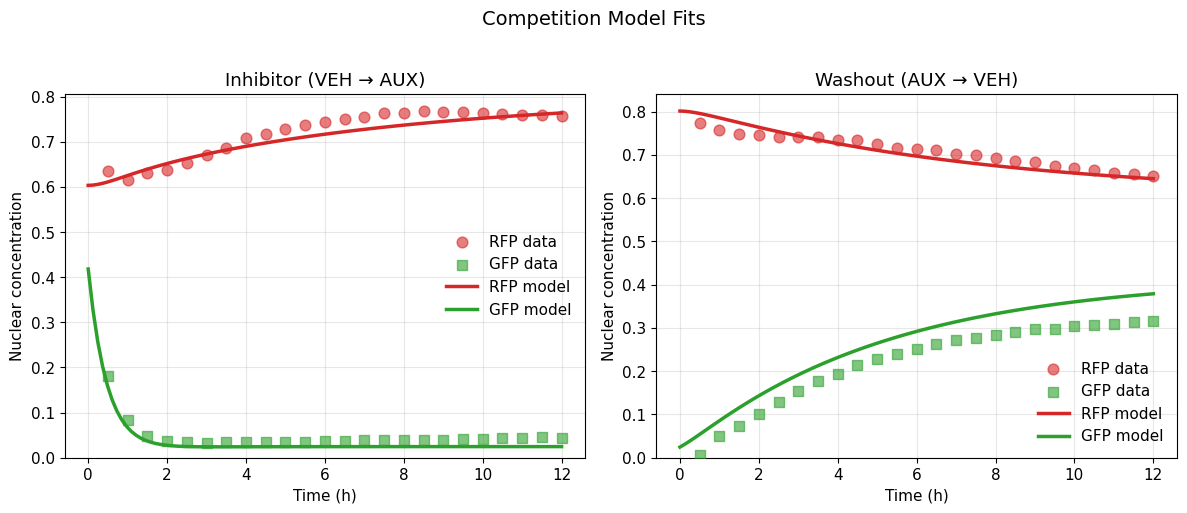

In [ ]:
# Get predictions with best parameters
_, predictions = objective_function(
    best_params_array, data_averaged, return_predictions=True
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    data = data_averaged[code]
    pred = predictions[code]

    # Plot data
    ax.scatter(
        data["time"],
        data["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        label="RFP data",
        zorder=3,
    )
    ax.scatter(
        data["time"],
        data["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        label="GFP data",
        zorder=3,
    )

    # Plot model
    ax.plot(
        pred["time"], pred["A_n"], color=colors["rfp"], linewidth=2.5, label="RFP model"
    )
    ax.plot(
        pred["time"], pred["B_n"], color=colors["gfp"], linewidth=2.5, label="GFP model"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Nuclear concentration")
    ax.set_title(titles[code])
    ax.legend(frameon=False)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

fig.suptitle("Competition Model Fits", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Validation: Algebraic vs Integrated Steady State

`models.competition_steady_state` solves the steady state algebraically rather than integrating the
ODEs to $t = 200$ h. This cell verifies that simplification, at several $K_M$ spanning the
range used in the sweep below.

1. Compare the algebraic solution against `integrate_competition_to_steady_state`
2. Compare both the algebraic and steady-state integration against the endpoint of
   a long numerical integration started from an initial condition
   deliberately away from steady state;

      K_M  |alg - ODE ss|  |alg - traj end|     t(alg)   t(ODE ss)
  1.0e-09        3.79e-10          1.29e-09      0.03ms      1.08ms
  1.0e-06        3.79e-10          1.29e-09      0.06ms      1.29ms
  1.0e-03        6.87e-10          8.10e-08      0.03ms      1.17ms
  1.0e-01        3.05e-10          5.68e-09      0.02ms      1.20ms


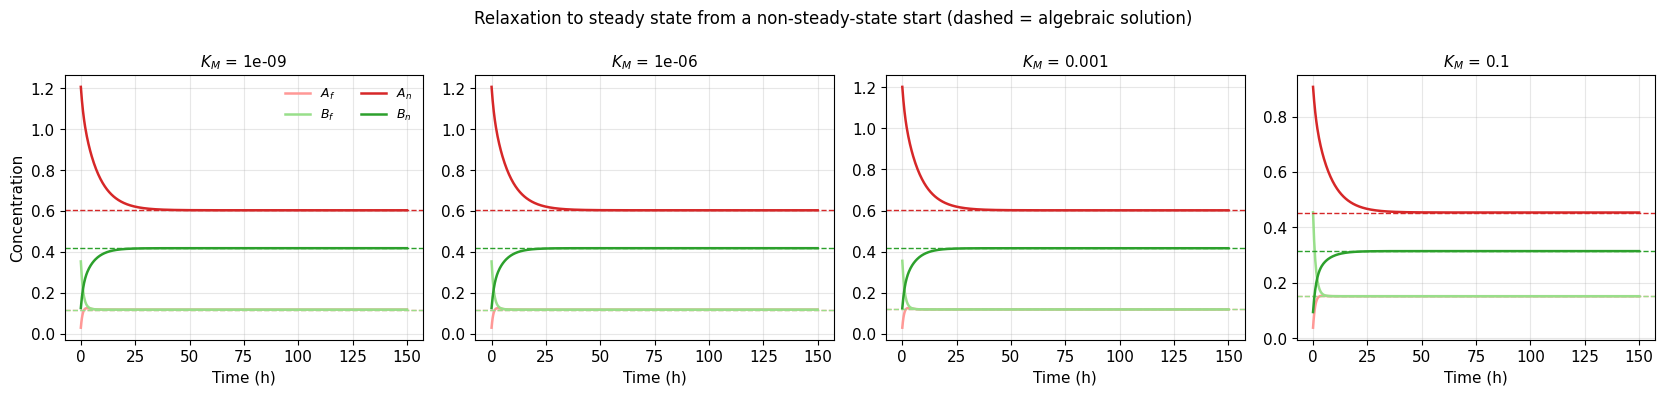

In [ ]:
from models import integrate_competition_to_steady_state as _integrate_ss

VALIDATION_K_M = [1e-9, 1e-6, 1e-3, 1e-1]
Y0_FACTORS = np.array([0.25, 3.0, 2.0, 0.3])  # start well away from steady state
T_END_VALIDATION = 150.0

fig, axes = plt.subplots(1, len(VALIDATION_K_M), figsize=(4.2 * len(VALIDATION_K_M), 4))
axes = np.atleast_1d(axes)
labels = ["$A_f$", "$B_f$", "$A_n$", "$B_n$"]
colours = ["#ff9896", "#98df8a", "#d62728", "#2ca02c"]

print(
    f"{'K_M':>9} {'|alg - ODE ss|':>15} {'|alg - traj end|':>17} "
    f"{'t(alg)':>10} {'t(ODE ss)':>11}"
)

for ax, K_M_v in zip(axes, VALIDATION_K_M):
    p_v = {
        "k_s": k_s,
        "k_import": V_max,
        "F_total": 1.0,
        "K_M": K_M_v,
        "delta_f_A": delta_f_A,
    }

    t0 = time.perf_counter()
    ss_alg = competition_steady_state(p_v, delta_f_A, DELTA_N_A, DELTA_N_B)
    t_alg = time.perf_counter() - t0

    t0 = time.perf_counter()
    ss_ode = _integrate_ss(p_v, delta_f_A, DELTA_N_A, DELTA_N_B)
    t_ode = time.perf_counter() - t0

    # Relax from an initial condition deliberately away from steady state.
    y0 = ss_alg * Y0_FACTORS
    traj, times = simulate_competition_trajectory(
        p_v, delta_f_A, DELTA_N_A, DELTA_N_B, T_END_VALIDATION, y0, n_points=600
    )

    for idx, (lab, col) in enumerate(zip(labels, colours)):
        ax.plot(times, traj[idx], color=col, lw=1.8, label=lab)
        ax.axhline(ss_alg[idx], color=col, ls="--", lw=1.0)

    ax.set_xlabel("Time (h)")
    ax.set_title(f"$K_M$ = {K_M_v:g}", fontsize=11)
    ax.grid(alpha=0.3)

    print(
        f"{K_M_v:9.1e} {np.max(np.abs(ss_alg - ss_ode)):15.2e} "
        f"{np.max(np.abs(ss_alg - traj[:, -1])):17.2e} "
        f"{1000*t_alg:9.2f}ms {1000*t_ode:9.2f}ms"
    )

axes[0].set_ylabel("Concentration")
axes[0].legend(frameon=False, fontsize=9, ncol=2)
fig.suptitle(
    "Relaxation to steady state from a non-steady-state start "
    "(dashed = algebraic solution)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Parameter dependence

### Dependence on $R_{\mathrm{cyt}}$

The measured cytoplasmic:nuclear ratio is an input, not a fitted quantity. We now examine
how the model fit changes when we alter its value. Here $R_{\mathrm{cyt}}$ is scanned from
0.05 to 0.5 and the model is re-fit at each value, with the same two-sided constraint applied
throughout.

Use `SCAN_DE_MAXITER` to alter global (differential evolution) optimisation.

In [9]:
R_VALUES = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])

SCAN_DE_MAXITER = 200
SCAN_DE_POPSIZE = 10

scan_rows = []
scan_thetas = {}
theta_prev = best_params_array.copy()

for R in R_VALUES:
    t0 = time.perf_counter()

    result_global_R = differential_evolution(
        _objective_log,
        bounds_log,
        args=(data_averaged, R),
        maxiter=SCAN_DE_MAXITER,
        popsize=SCAN_DE_POPSIZE,
        seed=RANDOM_SEED,
        workers=1,
        updating="deferred",
        tol=1e-6,
    )

    best = (np.inf, None)
    for x0 in [_to_linear(result_global_R.x), theta_prev, best_params_array]:
        try:
            res = minimize(
                _objective_log,
                _to_log(x0),
                args=(data_averaged, R),
                method="L-BFGS-B",
                bounds=bounds_log,
            )
        except Exception:
            continue
        if res.fun < best[0]:
            best = (res.fun, _to_linear(res.x))

    theta_best = best[1] if best[1] is not None else theta_prev
    scan_thetas[R] = theta_best
    theta_prev = theta_best

    d = fit_diagnostics(theta_best, cyto_nuc_ratio=R)
    d["R"] = R
    d["on_floor"] = d["F_total"] <= 1.01 * d["F_floor"]
    scan_rows.append(d)

    print(
        f"R = {R:5.3f}:  data loss = {d['data_loss']:.5f}  "
        f"K_M = {d['K_M']:.3g}  degron = {d['delta_n_B_degron']:.3f}  "
        f"F_total = {d['F_total']:.3g}"
        f"   [{time.perf_counter() - t0:.1f}s]"
    )

scan = pd.DataFrame(scan_rows)
print("\nScan complete.")

R = 0.050:  data loss = 0.16434  K_M = 2.31e-09  degron = 2.765  F_total = 0.00157   [31.4s]
R = 0.100:  data loss = 0.11558  K_M = 4.2e-09  degron = 2.428  F_total = 0.00305   [24.7s]
R = 0.150:  data loss = 0.09065  K_M = 7.86e-09  degron = 2.198  F_total = 0.00448   [25.4s]
R = 0.200:  data loss = 0.07549  K_M = 1.12e-09  degron = 2.034  F_total = 0.00589   [24.3s]
R = 0.250:  data loss = 0.06546  K_M = 6.12e-09  degron = 1.911  F_total = 0.00727   [24.0s]
R = 0.300:  data loss = 0.05842  K_M = 0.00263  degron = 1.824  F_total = 0.00868   [28.9s]
R = 0.350:  data loss = 0.05243  K_M = 0.0117  degron = 1.776  F_total = 0.0102   [27.8s]
R = 0.400:  data loss = 0.04856  K_M = 0.0117  degron = 1.776  F_total = 0.0115   [30.2s]
R = 0.450:  data loss = 0.04279  K_M = 0.0341  degron = 1.690  F_total = 0.0131   [28.1s]
R = 0.500:  data loss = 0.03914  K_M = 0.048  degron = 1.655  F_total = 0.0146   [29.3s]

Scan complete.


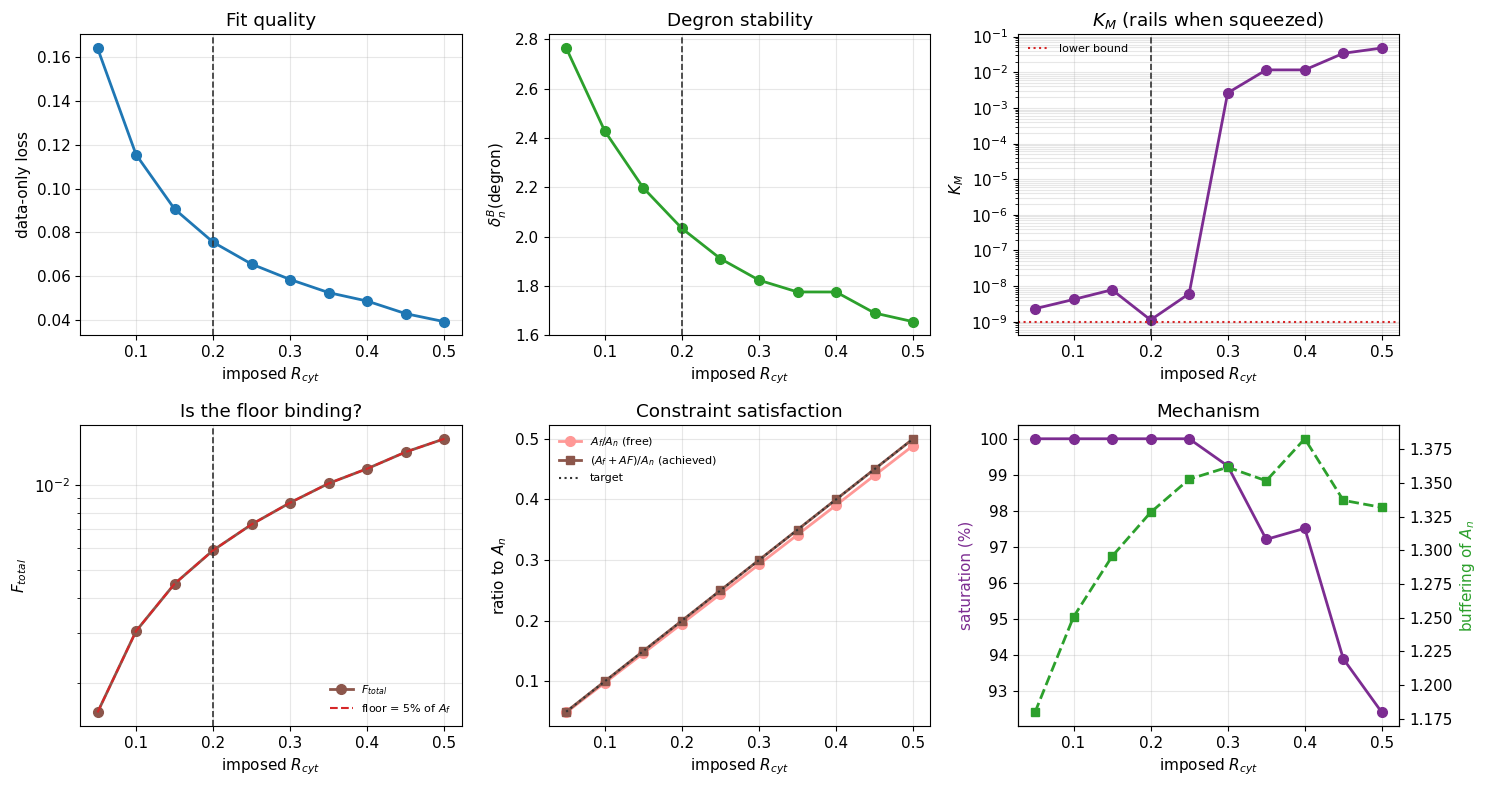

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# --- data loss ---
ax = axes[0, 0]
ax.plot(scan["R"], scan["data_loss"], "o-", color="#1f77b4", lw=2, ms=7)
ax.axvline(CYTO_NUC_RATIO, ls="--", color="#333333", lw=1.2)
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("data-only loss")
ax.set_title("Fit quality")
ax.grid(alpha=0.3)

# --- degron ---
ax = axes[0, 1]
ax.plot(scan["R"], scan["delta_n_B_degron"], "o-", color="#2ca02c", lw=2, ms=7)
ax.axvline(CYTO_NUC_RATIO, ls="--", color="#333333", lw=1.2)
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("$\\delta_n^B$(degron)")
ax.set_title("Degron stability")
ax.grid(alpha=0.3)

# --- K_M ---
ax = axes[0, 2]
ax.plot(scan["R"], scan["K_M"], "o-", color="#7c2c91", lw=2, ms=7)
ax.axhline(10 ** bounds_log[2][0], ls=":", color="#d62728", lw=1.5, label="lower bound")
ax.axvline(CYTO_NUC_RATIO, ls="--", color="#333333", lw=1.2)
ax.set_yscale("log")
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("$K_M$")
ax.set_title("$K_M$ (rails when squeezed)")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3, which="both")

# --- F_total vs its floor ---
ax = axes[1, 0]
ax.plot(
    scan["R"], scan["F_total"], "o-", color="#8c564b", lw=2, ms=7, label="$F_{total}$"
)
ax.plot(
    scan["R"],
    scan["F_floor"],
    "--",
    color="#d62728",
    lw=1.5,
    label=f"floor = {F_TOTAL_FLOOR_FRAC:.0%} of $A_f$",
)
ax.axvline(CYTO_NUC_RATIO, ls="--", color="#333333", lw=1.2)
ax.set_yscale("log")
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("$F_{total}$")
ax.set_title("Is the floor binding?")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3, which="both")

# --- cytoplasmic composition ---
ax = axes[1, 1]
ax.plot(
    scan["R"],
    scan["free_ratio"],
    "o-",
    color="#ff9896",
    lw=2,
    ms=7,
    label="$A_f/A_n$ (free)",
)
ax.plot(
    scan["R"],
    scan["cyto_nuc"],
    "s-",
    color="#8c564b",
    lw=2,
    ms=6,
    label="$(A_f+AF)/A_n$ (achieved)",
)
ax.plot(scan["R"], scan["R"], ":", color="#333333", lw=1.5, label="target")
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("ratio to $A_n$")
ax.set_title("Constraint satisfaction")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

# --- saturation and buffering ---
ax = axes[1, 2]
ax.plot(
    scan["R"],
    100 * scan["saturation"],
    "o-",
    color="#7c2c91",
    lw=2,
    ms=7,
    label="saturation (%)",
)
ax2 = ax.twinx()
ax2.plot(
    scan["R"], scan["buffering"], "s--", color="#2ca02c", lw=2, ms=6, label="buffering"
)
ax2.set_ylabel("buffering of $A_n$", color="#2ca02c")
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("saturation (%)", color="#7c2c91")
ax.set_title("Mechanism")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("competition_Rcyt_scan.pdf", bbox_inches="tight")
plt.show()

At all values $F_\mathrm{total}$ is pushed to the lower limit, because keeping $F$ "limiting" allows the best competition. The floor is therefore an important constraint. All parameters acheive the target $R_{cyt}$. However, fit quality and buffering becomes progressively worse for $R_{cyt}$ below 0.4, because the degron $\delta_{\mathrm{degron}}$ is additive to $\delta^B_f$ in the cytoplasm and to $\delta^B_n$ in the nucleus. At low $R_{cyt}$, the degron has less of an effect in the cytoplasm (due to lower $B_f$) so "buffering is reduced". This can be seen as a trade-off between the ideal $\delta_{\mathrm{degron}}$ from the nuclear fit and the upwards pressure on this parameter at lower $R_{cyt}$ values. The measured value of $R_{cyt}$ is a reasonable value producing predictions consistent with the conclusions.

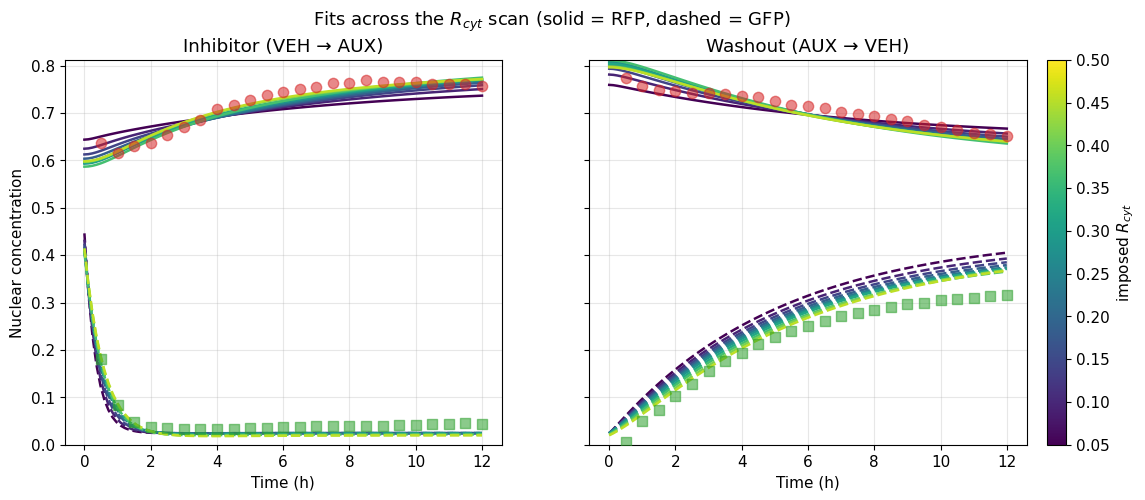

In [ ]:
# Model curves across the scan, overlaid on the data
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(R_VALUES)))
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code_ in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    d = data_averaged[code_]
    ax.scatter(d["time"], d["rfp"], color="#d62728", alpha=0.55, s=55, zorder=4)
    ax.scatter(
        d["time"], d["gfp"], color="#2ca02c", alpha=0.55, s=55, marker="s", zorder=4
    )
    for col, R in zip(cmap, R_VALUES):
        _, preds = objective_function(
            scan_thetas[R], data_averaged, return_predictions=True, cyto_nuc_ratio=R
        )
        ax.plot(preds[code_]["time"], preds[code_]["A_n"], color=col, lw=1.8)
        ax.plot(preds[code_]["time"], preds[code_]["B_n"], color=col, lw=1.8, ls="--")
    ax.set_xlabel("Time (h)")
    ax.set_title(titles[code_])
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Nuclear concentration")
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis, norm=plt.Normalize(vmin=R_VALUES.min(), vmax=R_VALUES.max())
)
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("imposed $R_{cyt}$")
fig.suptitle("Fits across the $R_{cyt}$ scan (solid = RFP, dashed = GFP)", fontsize=13)
plt.show()

#### Flux partitioning

We plot the flux partition across the range of $R_{\mathrm{cyt}}$ values that have been fit to ensure that
constraining the free pool may result in unrealistic flux into the cytoplasmic decay pathway

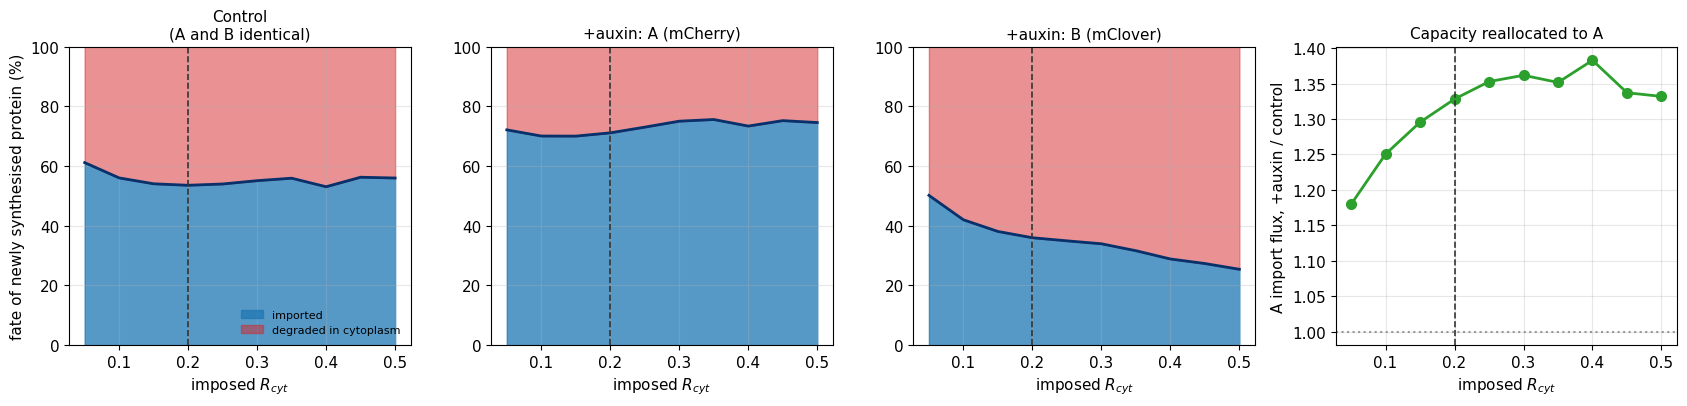

In [ ]:
part_rows = []
for R in R_VALUES:
    df = flux_partitioning(scan_thetas[R])
    df["R"] = R
    part_rows.append(df)

partition_scan = pd.concat(part_rows, ignore_index=True)

# Flux-level buffering: A's import flux under auxin relative to control
imp = partition_scan.pivot_table(
    index="R", columns=["protein", "condition"], values="import_flux"
)
buffer_flux = imp[("A (mCherry)", "+auxin")] / imp[("A (mCherry)", "control")]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))

panels = [
    ("control", "A (mCherry)", "Control\n(A and B identical)"),
    ("+auxin", "A (mCherry)", "+auxin: A (mCherry)"),
    ("+auxin", "B (mClover)", "+auxin: B (mClover)"),
]

for ax, (cond, prot, title) in zip(axes, panels):
    sel = partition_scan[
        (partition_scan["condition"] == cond) & (partition_scan["protein"] == prot)
    ].sort_values("R")
    f_imp = 100 * sel["f_imported"].to_numpy()
    ax.fill_between(sel["R"], 0, f_imp, color="#1f77b4", alpha=0.75, label="imported")
    ax.fill_between(
        sel["R"], f_imp, 100, color="#d62728", alpha=0.5, label="degraded in cytoplasm"
    )
    ax.plot(sel["R"], f_imp, color="#08306b", lw=2)
    ax.axvline(CYTO_NUC_RATIO, ls="--", color="#333333", lw=1.2)
    ax.set_xlabel("imposed $R_{cyt}$")
    ax.set_ylim(0, 100)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("fate of newly synthesised protein (%)")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")

ax = axes[3]
ax.plot(buffer_flux.index, buffer_flux.values, "o-", color="#2ca02c", lw=2, ms=7)
ax.axhline(1.0, ls=":", color="#999999", lw=1.5)
ax.axvline(CYTO_NUC_RATIO, ls="--", color="#333333", lw=1.2)
ax.set_xlabel("imposed $R_{cyt}$")
ax.set_ylabel("A import flux, +auxin / control")
ax.set_title("Capacity reallocated to A", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Dependence on $K_M$

$K_M$ is poorly constrained by the data as it appears to have little influence on the fit. We now investigate how the recovered parameters, the saturation and capacity of the import step, and the partitioning of newly synthesised protein between import and cytoplasmic degradation all vary with different (imposed) $K_M$, compared to the one from the best fit.

In [12]:
K_M_VALUES = np.array([1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])

# R_cyt is held fixed for this sweep; K_M is fixed at each point and the remaining
# four parameters are refitted.
K_M_SWEEP_R = 0.2

bounds_log_KM = [b for i, b in enumerate(bounds_log) if i != 2]  # drop K_M
PARAM_NAMES_KM = ["k_s", "V_max", "delta_f_A", "delta_n_B_degron"]


def _theta_with_KM(theta4_log, K_M_fixed):
    """Insert the fixed K_M into a 4-parameter (log10) coordinate vector."""
    k_s_, V_max_, delta_f_A_ = 10.0 ** np.asarray(theta4_log[:3])
    return np.array([k_s_, V_max_, K_M_fixed, delta_f_A_, theta4_log[3]])


def _to_log_KM(theta):
    """Full 5-parameter theta -> 4-parameter optimizer coordinates (K_M dropped)."""
    k_s_, V_max_, _, delta_f_A_, degron_ = theta
    return np.array([np.log10(k_s_), np.log10(V_max_), np.log10(delta_f_A_), degron_])


def _objective_KM(theta4_log, data_averaged, K_M_fixed, cyto_nuc_ratio):
    return objective_function(
        _theta_with_KM(theta4_log, K_M_fixed),
        data_averaged,
        cyto_nuc_ratio=cyto_nuc_ratio,
    )


km_rows = []
km_thetas = {}
theta_prev = np.asarray(
    scan_thetas.get(K_M_SWEEP_R, best_params_array), dtype=float
).copy()

for K_M_fixed in K_M_VALUES:
    t0 = time.perf_counter()

    result_global_KM = differential_evolution(
        _objective_KM,
        bounds_log_KM,
        args=(data_averaged, K_M_fixed, K_M_SWEEP_R),
        maxiter=SCAN_DE_MAXITER,
        popsize=SCAN_DE_POPSIZE,
        seed=RANDOM_SEED,
        workers=1,
        updating="deferred",
        tol=1e-6,
    )

    best = (np.inf, None)
    starts = [
        _theta_with_KM(result_global_KM.x, K_M_fixed),
        theta_prev,
        best_params_array,
    ]
    for x0 in starts:
        try:
            res = minimize(
                _objective_KM,
                _to_log_KM(x0),
                args=(data_averaged, K_M_fixed, K_M_SWEEP_R),
                method="L-BFGS-B",
                bounds=bounds_log_KM,
            )
        except Exception:
            continue
        if res.fun < best[0]:
            best = (res.fun, _theta_with_KM(res.x, K_M_fixed))

    theta_best = best[1] if best[1] is not None else theta_prev
    km_thetas[K_M_fixed] = theta_best
    theta_prev = theta_best

    d = fit_diagnostics(theta_best, cyto_nuc_ratio=K_M_SWEEP_R)
    d["K_M_fixed"] = K_M_fixed
    d["on_floor"] = d["F_total"] <= 1.01 * d["F_floor"]
    km_rows.append(d)

    print(
        f"K_M = {K_M_fixed:8.1e}:  data loss = {d['data_loss']:.5f}  "
        f"k_s = {d['k_s']:.4f}  V_max = {d['V_max']:.4f}  "
        f"delta_f_A = {d['delta_f_A']:.4f}  degron = {d['delta_n_B_degron']:.3f}"
        f"{'  (F_total on floor)' if d['on_floor'] else ''}"
        f"   [{time.perf_counter() - t0:.1f}s]"
    )

km_scan = pd.DataFrame(km_rows)
print("\nK_M sweep complete.")

K_M =  1.0e-10:  data loss = 0.07549  k_s = 0.1523  V_max = 0.1632  delta_f_A = 0.6007  degron = 2.034  (F_total on floor)   [15.2s]
K_M =  1.0e-09:  data loss = 0.07549  k_s = 0.1523  V_max = 0.1632  delta_f_A = 0.6007  degron = 2.034  (F_total on floor)   [15.5s]
K_M =  1.0e-08:  data loss = 0.07549  k_s = 0.1523  V_max = 0.1632  delta_f_A = 0.6007  degron = 2.034  (F_total on floor)   [15.4s]
K_M =  1.0e-07:  data loss = 0.07549  k_s = 0.1523  V_max = 0.1632  delta_f_A = 0.6004  degron = 2.034  (F_total on floor)   [14.4s]
K_M =  1.0e-06:  data loss = 0.07549  k_s = 0.1523  V_max = 0.1632  delta_f_A = 0.6007  degron = 2.034  (F_total on floor)   [14.2s]
K_M =  1.0e-05:  data loss = 0.07549  k_s = 0.1523  V_max = 0.1632  delta_f_A = 0.6007  degron = 2.034  (F_total on floor)   [15.7s]
K_M =  1.0e-04:  data loss = 0.07554  k_s = 0.1524  V_max = 0.1633  delta_f_A = 0.6009  degron = 2.034  (F_total on floor)   [15.0s]
K_M =  1.0e-03:  data loss = 0.07600  k_s = 0.1527  V_max = 0.1642  d

In [ ]:
# Combine the fit diagnostics with the flux partitioning at each K_M
km_flux_rows = []
for K_M_fixed in K_M_VALUES:
    fp = flux_partitioning(km_thetas[K_M_fixed])
    rec = {"K_M_fixed": K_M_fixed}
    for _, r in fp.iterrows():
        tag = "ctrl" if r["condition"] == "control" else "aux"
        prot = "A" if r["protein"].startswith("A") else "B"
        rec[f"f_imp_{prot}_{tag}"] = r["f_imported"]
        rec[f"f_deg_{prot}_{tag}"] = r["f_cyto_degraded"]
        rec[f"impflux_{prot}_{tag}"] = r["import_flux"]
    km_flux_rows.append(rec)

km_summary = km_scan.merge(pd.DataFrame(km_flux_rows), on="K_M_fixed")

# Derived quantities
km_summary["capacity_frac"] = km_summary["V_max"] / (2 * km_summary["k_s"])
km_summary["buffering_flux"] = (
    km_summary["impflux_A_aux"] / km_summary["impflux_A_ctrl"]
)
km_summary["loss_ratio"] = km_summary["data_loss"] / km_summary["data_loss"].min()

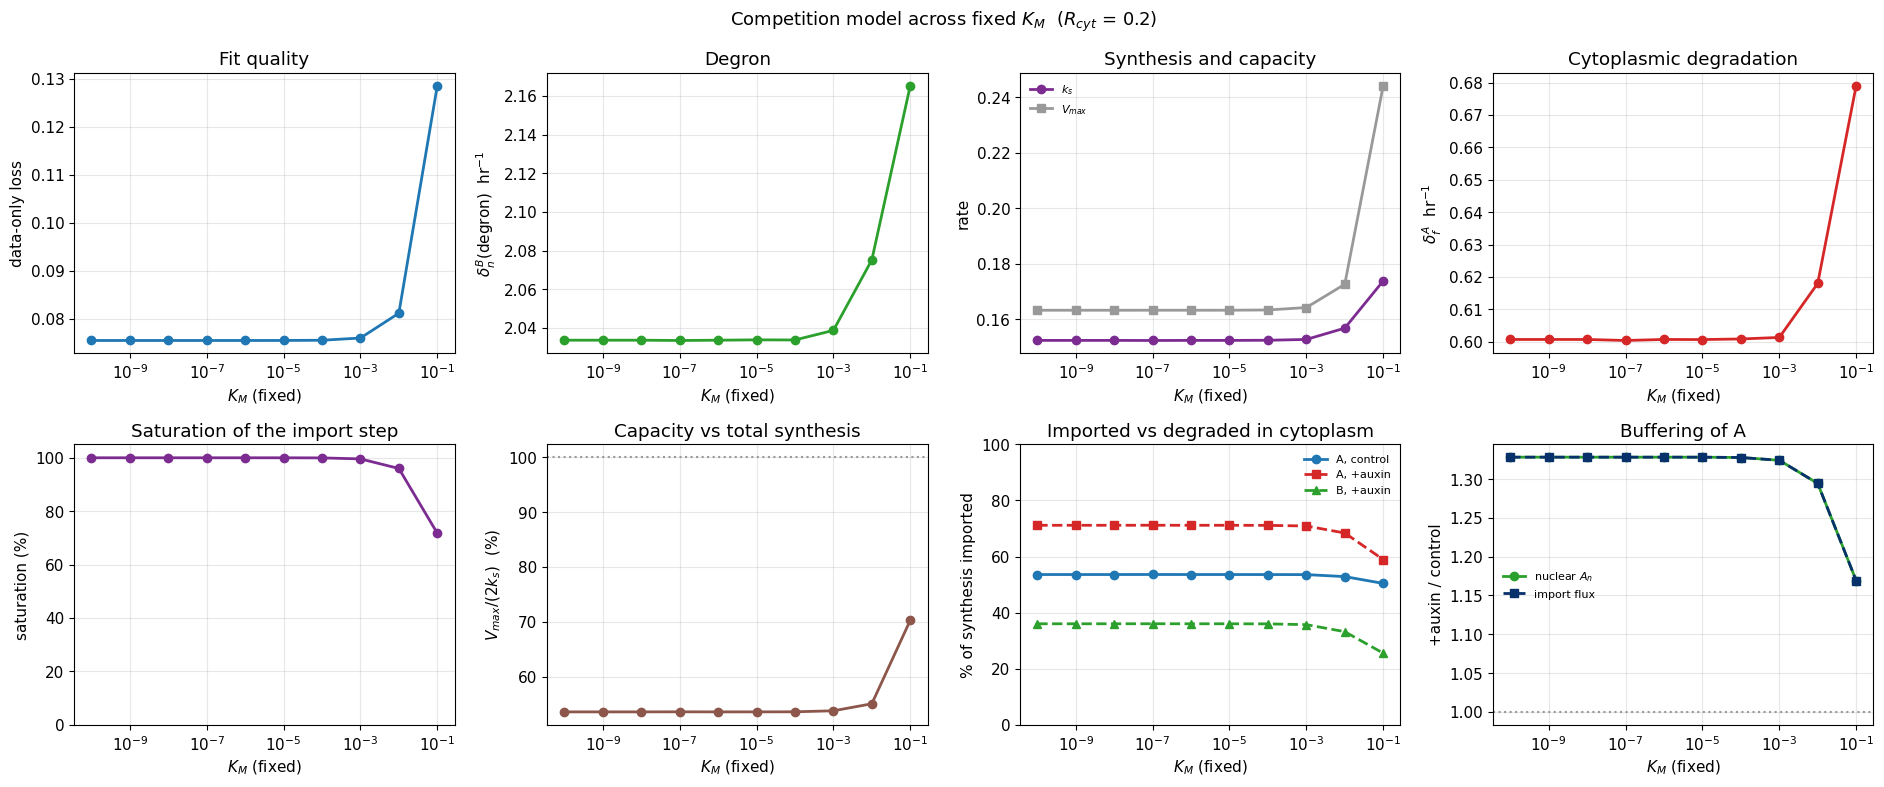

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
x = km_summary["K_M_fixed"]

# --- data loss ---
ax = axes[0, 0]
ax.plot(x, km_summary["data_loss"], "o-", color="#1f77b4", lw=2, ms=6)
ax.set_xscale("log")
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("data-only loss")
ax.set_title("Fit quality")
ax.grid(alpha=0.3, which="both")

# --- degron ---
ax = axes[0, 1]
ax.plot(x, km_summary["delta_n_B_degron"], "o-", color="#2ca02c", lw=2, ms=6)
ax.set_xscale("log")
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("$\\delta_n^B$(degron)  hr$^{-1}$")
ax.set_title("Degron")
ax.grid(alpha=0.3, which="both")

# --- k_s and V_max ---
ax = axes[0, 2]
ax.plot(x, km_summary["k_s"], "o-", color="#7c2c91", lw=2, ms=6, label="$k_s$")
ax.plot(x, km_summary["V_max"], "s-", color="#999999", lw=2, ms=6, label="$V_{max}$")
ax.set_xscale("log")
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("rate")
ax.set_title("Synthesis and capacity")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3, which="both")

# --- delta_f_A ---
ax = axes[0, 3]
ax.plot(x, km_summary["delta_f_A"], "o-", color="#d62728", lw=2, ms=6)
ax.set_xscale("log")
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("$\\delta_f^A$  hr$^{-1}$")
ax.set_title("Cytoplasmic degradation")
ax.grid(alpha=0.3, which="both")

# --- saturation ---
ax = axes[1, 0]
ax.plot(x, 100 * km_summary["saturation"], "o-", color="#7c2c91", lw=2, ms=6)
ax.set_xscale("log")
ax.set_ylim(0, 105)
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("saturation (%)")
ax.set_title("Saturation of the import step")
ax.grid(alpha=0.3, which="both")

# --- capacity relative to synthesis ---
ax = axes[1, 1]
ax.plot(x, 100 * km_summary["capacity_frac"], "o-", color="#8c564b", lw=2, ms=6)
ax.axhline(100, ls=":", color="#999999", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("$V_{max}/(2k_s)$  (%)")
ax.set_title("Capacity vs total synthesis")
ax.grid(alpha=0.3, which="both")

# --- flux partitioning ---
ax = axes[1, 2]
ax.plot(
    x,
    100 * km_summary["f_imp_A_ctrl"],
    "o-",
    color="#1f77b4",
    lw=2,
    ms=6,
    label="A, control",
)
ax.plot(
    x,
    100 * km_summary["f_imp_A_aux"],
    "s--",
    color="#d62728",
    lw=2,
    ms=6,
    label="A, +auxin",
)
ax.plot(
    x,
    100 * km_summary["f_imp_B_aux"],
    "^--",
    color="#2ca02c",
    lw=2,
    ms=6,
    label="B, +auxin",
)
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("% of synthesis imported")
ax.set_title("Imported vs degraded in cytoplasm")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3, which="both")

# --- buffering ---
ax = axes[1, 3]
ax.plot(
    x, km_summary["buffering"], "o-", color="#2ca02c", lw=2, ms=6, label="nuclear $A_n$"
)
ax.plot(
    x,
    km_summary["buffering_flux"],
    "s--",
    color="#08306b",
    lw=2,
    ms=6,
    label="import flux",
)
ax.axhline(1.0, ls=":", color="#999999", lw=1.5)
ax.set_xscale("log")
ax.set_xlabel("$K_M$ (fixed)")
ax.set_ylabel("+auxin / control")
ax.set_title("Buffering of A")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3, which="both")

fig.suptitle(
    f"Competition model across fixed $K_M$  ($R_{{cyt}}$ = {K_M_SWEEP_R})", fontsize=13
)
plt.tight_layout()
plt.show()

### Select a final $K_M$

Set `K_M_SELECTED` to the value you want to carry forward, then re-run this cell. It plots the
corresponding fit against the data and writes
`fitted_parameters/competition_params_R0_2_manual_K_M.json`.

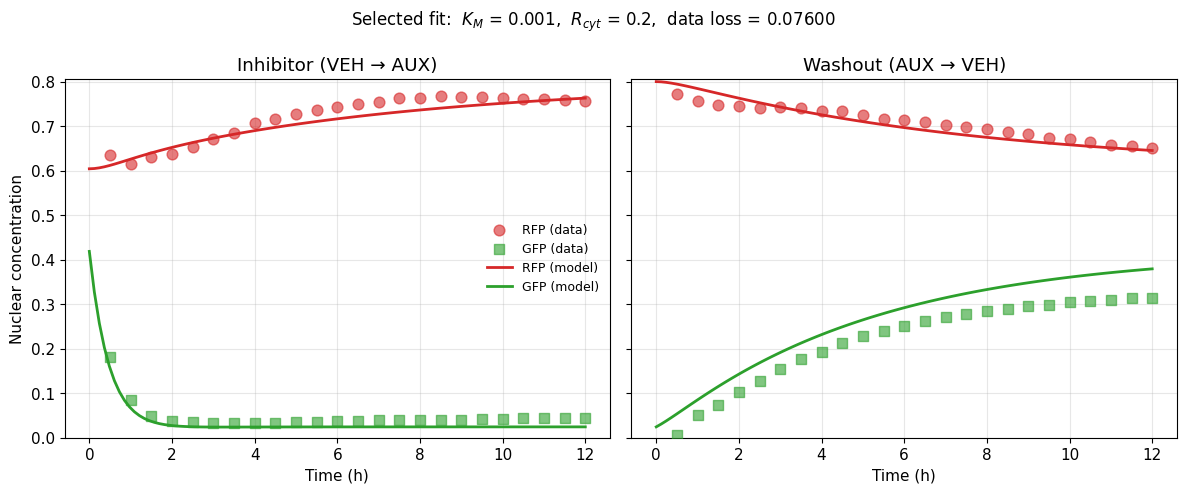

Selected K_M = 0.001   (R_cyt = 0.2)
  data loss   = 0.07600
  k_s         = 0.1527 hr⁻¹
  V_max       = 0.1642
  delta_f_A   = 0.6013 hr⁻¹
  degron      = 2.0387 hr⁻¹
  F_total     = 0.005898   k_import = 27.84 hr⁻¹
  saturation  = 99.6%   capacity/synthesis = 53.8%
  buffering   = 1.324

Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/competition_params_R0_2_manual_K_M.json


In [ ]:
K_M_SELECTED = 1e-4

if K_M_SELECTED not in km_thetas:
    K_M_SELECTED = min(
        km_thetas, key=lambda v: abs(np.log10(v) - np.log10(K_M_SELECTED))
    )
    print(f"Requested K_M not in the sweep; using nearest value {K_M_SELECTED:g}\n")

theta_sel = km_thetas[K_M_SELECTED]
k_s_sel, V_max_sel, K_M_sel, delta_f_A_sel, degron_sel = theta_sel
diag_sel = fit_diagnostics(theta_sel, cyto_nuc_ratio=K_M_SWEEP_R)

# --- plot the selected fit against the data ---
_, preds_sel = objective_function(
    theta_sel, data_averaged, return_predictions=True, cyto_nuc_ratio=K_M_SWEEP_R
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    d = data_averaged[code]
    pred = preds_sel[code]
    ax.scatter(
        d["time"],
        d["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        zorder=3,
        label="RFP (data)",
    )
    ax.scatter(
        d["time"],
        d["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        zorder=3,
        label="GFP (data)",
    )
    ax.plot(pred["time"], pred["A_n"], color=colors["rfp"], lw=2, label="RFP (model)")
    ax.plot(pred["time"], pred["B_n"], color=colors["gfp"], lw=2, label="GFP (model)")
    ax.set_xlabel("Time (h)")
    ax.set_title(titles[code])
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Nuclear concentration")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle(
    f"Selected fit:  $K_M$ = {K_M_SELECTED:g},  $R_{{cyt}}$ = {K_M_SWEEP_R},  "
    f"data loss = {diag_sel['data_loss']:.5f}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("competition_selected_fit_R0_2.pdf", bbox_inches="tight")
plt.show()

print(f"Selected K_M = {K_M_SELECTED:g}   (R_cyt = {K_M_SWEEP_R})")
print(f"  data loss   = {diag_sel['data_loss']:.5f}")
print(f"  k_s         = {k_s_sel:.4f} hr⁻¹")
print(f"  V_max       = {V_max_sel:.4f}")
print(f"  delta_f_A   = {delta_f_A_sel:.4f} hr⁻¹")
print(f"  degron      = {degron_sel:.4f} hr⁻¹")
print(
    f"  F_total     = {diag_sel['F_total']:.4g}   k_import = {diag_sel['k_import']:.4g} hr⁻¹"
)
print(
    f"  saturation  = {100*diag_sel['saturation']:.1f}%   "
    f"capacity/synthesis = {100*V_max_sel/(2*k_s_sel):.1f}%"
)
print(f"  buffering   = {diag_sel['buffering']:.3f}")

# --- save ---
selected_params = {
    "k_s": k_s_sel,
    "V_max": V_max_sel,
    "k_import": diag_sel["k_import"],
    "F_total": diag_sel["F_total"],
    "K_M": K_M_sel,
    "delta_f_A": delta_f_A_sel,
    "delta_n_B_degron": degron_sel,
    "delta_n_A": DELTA_N_A,
    "delta_n_B_factor": DELTA_N_B_FACTOR,
    "delta_n_B": DELTA_N_B,
    "cyto_nuc_ratio": K_M_SWEEP_R,
    "f_total_floor_frac": F_TOTAL_FLOOR_FRAC,
    "data_loss": diag_sel["data_loss"],
}

selected_path = Path("fitted_parameters/competition_params_R0_2_manual_K_M.json")
save_parameters(selected_params, selected_path)
print(f"\nSaved parameters to: {selected_path.resolve()}")

## QSSA Validity and Comparison with the Full Model

The reduced derivation assumed the assembly complex is in quasi-steady state: it must equilibrate faster
than the timescales on which the free species change. That requires two rates to exceed the
slow rates ($k_s/X_f$ and the degradation rates):

- the complex-loss rate $k_{\mathrm{off}} + k_{\mathrm{import}}$, and
- the binding rate $k_{\mathrm{on}} F_f$ (pseudo-first-order per free monomer), with
  $k_{\mathrm{on}} = (k_{\mathrm{off}} + k_{\mathrm{import}})/K_M$.

Only $K_M$ and $k_{\mathrm{import}}$ are fixed by the fit; $k_{\mathrm{off}}$ (equivalently
$k_{\mathrm{on}}$) is not identifiable. The first cell asks which $k_{\mathrm{off}}$ satisfy the
formal criterion. The second integrates the **full** six-species model (tracking the complexes
$AF$, $BF$ explicitly, no QSSA) and checks it reproduces the reduced-model fit.

Slow rates the complex must equilibrate faster than (hr^-1):
    k_s / A_f              =    1.294
    delta_f^A              =    0.601
    delta_f^B (+auxin)     =    2.640
    delta_n^A              =    0.135
    delta_n^B (+auxin)     =    2.234
    --> slowest            =    2.640

k_import = 27.836 hr^-1,  free factor F_f = 2.489e-05
Both QSSA rates exceed 10x the slowest rate once k_off >= 1053.3 hr^-1.


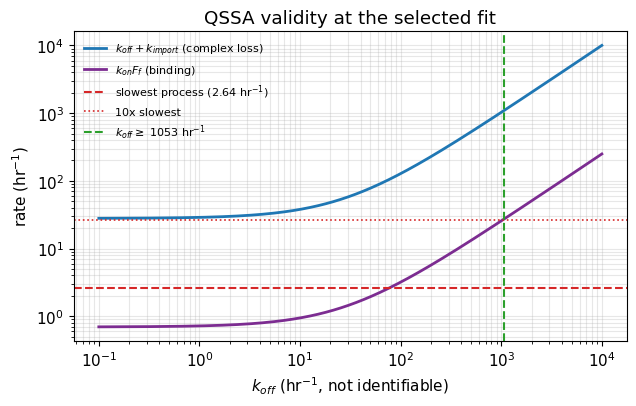

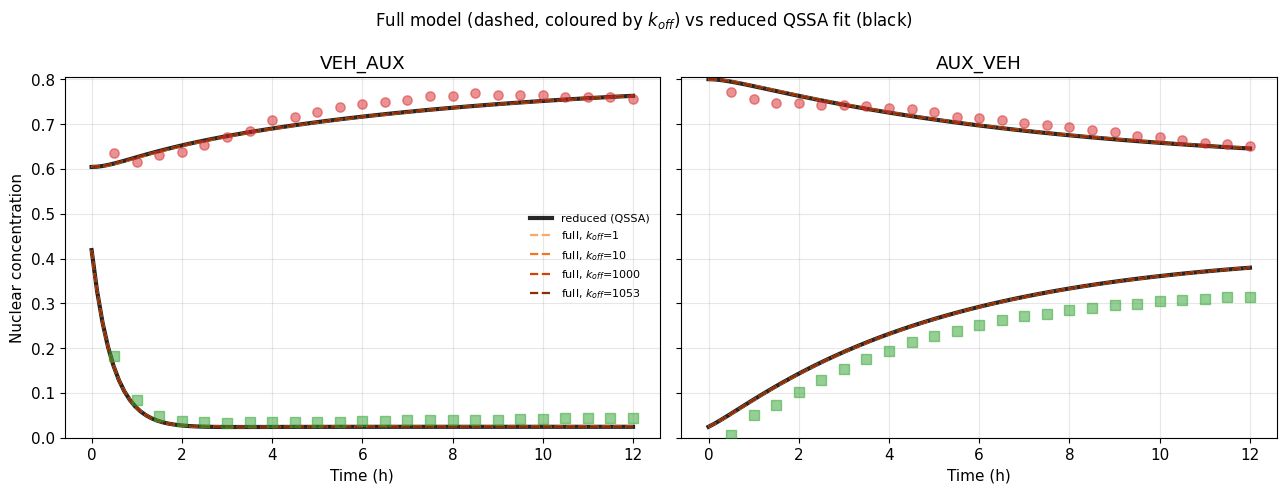


Max |full - reduced| over the fitting window (nuclear A and B):
    k_off =     1.0 hr^-1:  0.0029
    k_off =    10.0 hr^-1:  0.0029
    k_off =  1000.0 hr^-1:  0.0029
    k_off =  1053.0 hr^-1:  0.0029


In [28]:
p_sel = {
    "k_s": k_s_sel,
    "k_import": V_max_sel,
    "F_total": 1.0,
    "K_M": K_M_sel,
    "delta_f_A": delta_f_A_sel,
}
ss_sel = competition_steady_state(p_sel, delta_f_A_sel, DELTA_N_A, DELTA_N_B)
A_f_s, B_f_s = ss_sel[0], ss_sel[1]
D_sel = K_M_sel + A_f_s + B_f_s
k_import_sel = diag_sel["k_import"]
F_total_sel = diag_sel["F_total"]
F_f_sel = F_total_sel * K_M_sel / D_sel  # free factor at control steady state

slow_rates = {
    "k_s / A_f": k_s_sel / A_f_s,
    "delta_f^A": delta_f_A_sel,
    "delta_f^B (+auxin)": delta_f_A_sel + degron_sel,
    "delta_n^A": DELTA_N_A,
    "delta_n^B (+auxin)": DELTA_N_B + degron_sel,
}
slowest = max(slow_rates.values())

print("Slow rates the complex must equilibrate faster than (hr^-1):")
for name, val in slow_rates.items():
    print(f"    {name:22s} = {val:8.3f}")
print(f"    {'--> slowest':22s} = {slowest:8.3f}\n")

k_off_grid = np.logspace(-1, 4, 400)
complex_loss = k_off_grid + k_import_sel  # k_off + k_import
binding_rate = (complex_loss / K_M_sel) * F_f_sel  # k_on * F_f

factor = 10.0
ok = (complex_loss >= factor * slowest) & (binding_rate >= factor * slowest)
k_off_min = k_off_grid[ok][0] if ok.any() else np.inf
print(f"k_import = {k_import_sel:.3f} hr^-1,  free factor F_f = {F_f_sel:.4g}")
if np.isfinite(k_off_min):
    print(
        f"Both QSSA rates exceed {factor:.0f}x the slowest rate once "
        f"k_off >= {k_off_min:.1f} hr^-1."
    )
else:
    print("No k_off in the scanned range satisfies both conditions at 10x.")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(
    k_off_grid,
    complex_loss,
    color="#1f77b4",
    lw=2,
    label="$k_{off}+k_{import}$ (complex loss)",
)
ax.plot(k_off_grid, binding_rate, color="#7c2c91", lw=2, label="$k_{on} F_f$ (binding)")
ax.axhline(
    slowest,
    color="#d62728",
    ls="--",
    lw=1.5,
    label=f"slowest process ({slowest:.2f} hr$^{{-1}}$)",
)
ax.axhline(
    factor * slowest, color="#d62728", ls=":", lw=1.2, label=f"{factor:.0f}x slowest"
)
if np.isfinite(k_off_min):
    ax.axvline(
        k_off_min,
        color="#2ca02c",
        ls="--",
        lw=1.5,
        label=f"$k_{{off}} \\geq$ {k_off_min:.0f} hr$^{{-1}}$",
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$k_{off}$ (hr$^{-1}$, not identifiable)")
ax.set_ylabel("rate (hr$^{-1}$)")
ax.set_title("QSSA validity at the selected fit")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("competition_qssa_validity.pdf", bbox_inches="tight")
plt.show()


# --- 2) full model (no QSSA) vs the reduced fit ---
def full_model(t, y, k_off, delta_f_B, delta_n_B):
    """Unreduced system: complexes AF, BF tracked explicitly."""
    A_f, B_f, AF, BF, A_n, B_n = np.maximum(y, 0.0)
    k_on = (k_off + k_import_sel) / K_M_sel
    F_f = max(F_total_sel - AF - BF, 0.0)
    a_on, b_on = k_on * A_f * F_f, k_on * B_f * F_f
    return [
        k_s_sel - a_on + k_off * AF - delta_f_A_sel * A_f,
        k_s_sel - b_on + k_off * BF - delta_f_B * B_f,
        a_on - (k_off + k_import_sel) * AF,
        b_on - (k_off + k_import_sel) * BF,
        k_import_sel * AF - DELTA_N_A * A_n,
        k_import_sel * BF - delta_n_B * B_n,
    ]


def full_steady_state(k_off, delta_f_B, delta_n_B):
    """Steady state of the full model for given B rates (long integration)."""
    AF0 = F_total_sel * A_f_s / D_sel
    y0 = [A_f_s, B_f_s, AF0, AF0, ss_sel[2], ss_sel[3]]
    return solve_ivp(
        full_model,
        (0, 3000),
        y0,
        args=(k_off, delta_f_B, delta_n_B),
        method="LSODA",
        atol=1e-10,
        rtol=1e-9,
    ).y[:, -1]


def full_condition(k_off, code, t_end):
    """
    Full-model trajectory for one experimental condition, matching how the reduced
    model is driven: VEH_AUX starts at the control steady state and runs perturbed
    rates; AUX_VEH starts at the perturbed steady state and runs control rates.
    """
    dfB_c, dnB_c = delta_f_A_sel, DELTA_N_B
    dfB_p, dnB_p = delta_f_A_sel + degron_sel, DELTA_N_B + degron_sel
    if code == "VEH_AUX":
        y0 = full_steady_state(k_off, dfB_c, dnB_c)
        dfB, dnB = dfB_p, dnB_p
    else:  # AUX_VEH
        y0 = full_steady_state(k_off, dfB_p, dnB_p)
        dfB, dnB = dfB_c, dnB_c
    t_eval = np.linspace(0, t_end, 200)
    sol = solve_ivp(
        full_model,
        (0, t_end),
        y0,
        args=(k_off, dfB, dnB),
        method="LSODA",
        t_eval=t_eval,
        atol=1e-10,
        rtol=1e-9,
    )
    return sol.t, sol.y


K_OFF_TEST = sorted(
    {1.0, 10.0, round(k_off_min) if np.isfinite(k_off_min) else 100.0, 1000.0}
)

# reduced-model (QSSA) predictions
_, preds_red = objective_function(
    theta_sel, data_averaged, return_predictions=True, cyto_nuc_ratio=K_M_SWEEP_R
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
shades = plt.cm.Oranges(np.linspace(0.4, 0.95, len(K_OFF_TEST)))
for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    d = data_averaged[code]
    t_end = d["time"].max()
    ax.scatter(d["time"], d["rfp"], color="#d62728", alpha=0.5, s=45, zorder=4)
    ax.scatter(
        d["time"], d["gfp"], color="#2ca02c", alpha=0.5, s=45, marker="s", zorder=4
    )
    ax.plot(
        preds_red[code]["time"],
        preds_red[code]["A_n"],
        color="#000000",
        lw=3,
        alpha=0.85,
        label="reduced (QSSA)",
    )
    ax.plot(
        preds_red[code]["time"],
        preds_red[code]["B_n"],
        color="#000000",
        lw=3,
        alpha=0.85,
    )
    for k_off, c in zip(K_OFF_TEST, shades):
        t, y = full_condition(k_off, code, t_end)
        ax.plot(t, y[4], color=c, lw=1.6, ls="--", label=f"full, $k_{{off}}$={k_off:g}")
        ax.plot(t, y[5], color=c, lw=1.6, ls="--")
    ax.set_xlabel("Time (h)")
    ax.set_title(code)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Nuclear concentration")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(
    "Full model (dashed, coloured by $k_{off}$) vs reduced QSSA fit (black)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("competition_full_vs_qssa.pdf", bbox_inches="tight")
plt.show()

# quantitative agreement across both conditions and both proteins
print("\nMax |full - reduced| over the fitting window (nuclear A and B):")
for k_off in K_OFF_TEST:
    err = 0.0
    for code in ["VEH_AUX", "AUX_VEH"]:
        t, y = full_condition(k_off, code, data_averaged[code]["time"].max())
        for idx, key in [(4, "A_n"), (5, "B_n")]:
            red = np.interp(t, preds_red[code]["time"], preds_red[code][key])
            err = max(err, np.max(np.abs(y[idx] - red)))
    print(f"    k_off = {k_off:7.1f} hr^-1:  {err:.4f}")